[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/08_agents_tools_mcp/34_multi_agent_systems.ipynb)

# 📓 Notebook 34 — Multi-Agent Systems & Capstone

> **Module:** Agents, Tools & MCP · **Estimated time:** 80–100 min · **Difficulty:** Advanced

One agent with good tools solves most problems. But some tasks have **distinct sub-jobs** — analyse, then draft, then check — that are cleaner, more reliable, and more testable when handled by **specialist agents** under an **orchestrator**. This final notebook covers the multi-agent patterns that matter, their failure modes, and a **capstone** that combines everything in the module: agents (NB 31), robust tools (NB 32), and an MCP server (NB 33) into a working **support-operations assistant**.

100% offline. The deterministic stand-ins mark exactly where a real LLM plugs in.

> 🎯 **Where our running example finally lands.** The **AI support copilot** has grown up across the module: a bounded loop (NB 31), hardened tools (NB 32), an MCP server (NB 33). Here it becomes a *team* — an **analyst** that pulls the numbers, a **writer** that phrases them for a customer, and a **human** to escalate to when nobody can answer. By §6 these collaborate over the very MCP server you built, and the bonus project ships them as one `support_assistant(request)` function: the module's finished artifact.

> 🧭 **Mental model for the whole notebook: a multi-agent system is a team.** A *router / orchestrator* is the team lead — it reads each request, delegates it to the right *specialist*, and merges their outputs into one answer. The "wiring" between them sounds exotic but isn't: it's just **messages (text or dicts) passed between LLM calls**, exactly like ordinary function calls — except the *who-does-what* decision is made by an LLM instead of hard-coded. And like any team, more members means more capability but more coordination cost: hire a new specialist only when the role is *genuinely different*.

## 🎯 Learning objectives

By the end you can:

1. Decide **when multiple agents help — and when they're overkill**.
2. Build the **orchestrator–worker** pattern with specialist agents.
3. Implement **routing** and **handoff** between agents.
4. Share state safely via a **blackboard**.
5. **Evaluate** a multi-agent system end-to-end.
6. Assemble a **capstone**: orchestrator + specialists + tools + an MCP server.

## ✅ Prerequisites

Notebooks 31 (agents), 32 (tools), 33 (MCP). This notebook reuses their ideas; the code here is self-contained.

## 1. When to use more than one agent

Multi-agent is a **cost** (more calls, more latency, more ways to fail), so spend it only when it buys something:

| Use multiple agents when… | Use **one** agent when… |
|---|---|
| sub-tasks need **different tools / instructions** | one toolset and prompt covers it |
| you want **independent review** (writer + critic) | the task is a single straight line |
| sub-tasks run **in parallel** | steps are strictly sequential & cheap |
| roles map to **different owners/permissions** | everything shares one permission |

> Rule of thumb: start with one agent. Split only when a single prompt is doing two jobs badly.

### 🔬 What actually happens in a multi-agent system?

Section 1 told you *when* to reach for more than one agent. This section opens the box and shows *how the wiring works* — because the mechanics are simpler than the buzzword suggests.

A single agent tries to do everything with **one** LLM + **one** prompt + **one** toolbox:

```text
   request ──▶  ┌─────────────────────────┐  ──▶ answer
                │   ONE agent              │
                │   one prompt, all tools  │
                │   "be a mathematician    │
                │    AND a copywriter AND  │
                │    a support analyst..." │
                └─────────────────────────┘
```

A **multi-agent** system splits that one over-loaded prompt into **roles**. Each role is its own agent (its own LLM call + its own focused prompt + its own tools). An **orchestrator** (also called a *router*) looks at the request, decides *who should handle it*, hands the work to that specialist, and merges the result back:

```text
                       ┌───────────────────────────┐
   request ──────────▶ │   ORCHESTRATOR / ROUTER   │
                       │  "which specialist fits?" │
                       └─────────────┬─────────────┘
              classify + dispatch    │   (an LLM call, or here: a keyword rule)
            ┌──────────────┬─────────┴────────┬──────────────┐
            ▼              ▼                  ▼               ▼
      ┌───────────┐  ┌───────────┐     ┌───────────┐   (… add a role only
      │  math     │  │  writing  │     │  research │    when it's genuinely
      │ agent     │  │  agent    │     │  agent    │    different)
      │ tools:    │  │ tools:    │     │ tools:    │
      │  calc     │  │  none     │     │  search   │
      └─────┬─────┘  └─────┬─────┘     └─────┬─────┘
            └──────────────┴────────┬────────┘
                                    ▼
                        ┌───────────────────────┐
                        │  COMBINE the results  │ ──▶ final answer
                        └───────────────────────┘
```

The key realisation: **the "wiring" between agents is just messages.** When the orchestrator hands a task to the math agent, it is *passing a message* (a string, or a small dict of structured data). When the specialist answers, it *passes a message back*. That is the entire coordination mechanism — it looks exactly like a function call, except the *routing decision* is made by an LLM (or, offline, a deterministic rule) instead of being hard-coded.


### Single agent vs multi-agent — what actually changes

Same goal, two shapes. The difference is whether *one* prompt does every job, or whether the work is split across *roles* glued together by a router.

| | Single agent | Multi-agent (orchestrator + specialists) |
|---|---|---|
| **Prompts** | one prompt does every job | one focused prompt **per role** |
| **Tools** | all tools on one agent | each agent gets only the tools it needs |
| **Routing** | n/a — there's only one | an orchestrator **classifies** the request and **dispatches** |
| **Coordination** | none needed | **messages** passed between agents (text / dicts) |
| **Strength** | simple, cheap, one round-trip | each role is narrow → more reliable & testable |
| **Cost** | one LLM call | a routing call **+** one call per specialist used |
| **Failure surface** | small | larger — routing can mis-classify, hand-offs can drop data |
| **Best when** | one toolset + prompt covers it | sub-tasks are **genuinely distinct** jobs |

> 🎯 **The trade-off in one line.** More agents buy you **capability** (specialised, reliable roles) but cost you **coordination overhead, latency, and more places to fail.** Every extra agent is an extra LLM call and an extra hand-off that can mis-route or lose context — so split a task into agents only when the roles are *truly different*, not just because you can.


### 🧪 Proof — a mock multi-agent system you can run

Let's make it concrete and **fully offline**: no API, no network, just deterministic Python that mimics the *shape* of a real multi-agent system. We build two specialists, each a plain function standing in for *"an LLM with a focused role + tools"*:

- a **math agent** — evaluates a simple arithmetic request (its "tool" is `eval` on a safe expression),
- a **writing agent** — rewrites text into a polite one-liner.

In a real system each `..._agent(task)` would be a separate LLM call with that role as its system prompt. Here they are deterministic so the trace is identical every time you run it.


In [ ]:
import re

# ── Two specialist agents. Each takes a MESSAGE (a task string) and
#    returns a MESSAGE (a result dict). Offline = deterministic stand-ins
#    for "an LLM with a focused role + its own tools".

def math_agent(task: str) -> dict:
    """Role: do arithmetic. Tool: evaluate a safe numeric expression."""
    expr = re.sub(r"[^0-9+\-*/(). ]", "", task)          # keep only math chars
    try:
        value = eval(expr, {"__builtins__": {}}, {})     # tiny sandbox
        return {"agent": "math", "answer": f"The result is {value}."}
    except Exception:
        return {"agent": "math", "answer": "I couldn't parse that calculation."}

def writing_agent(task: str) -> dict:
    """Role: polish wording. Tool: none — pure text transformation."""
    topic = re.sub(r"(?i)^\s*write\s+a\s+sentence\s+about\s+", "", task).strip(" .")
    sentence = f"Here is a polished note about {topic}: we value {topic} greatly."
    return {"agent": "writing", "answer": sentence}

# Quick sanity check — call each specialist directly (no orchestrator yet):
print(math_agent("what is 12 * (3 + 4)?"))
print(writing_agent("write a sentence about customer trust"))


### The orchestrator — classify, dispatch, combine

Now the glue. `route_demo(task)` is the **orchestrator's brain**: it classifies the request and returns *which specialist should handle it*. Offline it's a keyword rule; in a real system this single decision is itself an LLM call ("given this request, which agent fits?"). Then `orchestrate(task)` **dispatches** the task to the chosen agent and **combines** the result into a final answer — printing the full routing + hand-off trace so you can watch the messages flow.


In [ ]:
# ── The orchestrator: a registry of specialists + a router that picks one.

SPECIALISTS = {"math": math_agent, "writing": writing_agent}

def route_demo(task: str) -> str:
    """The router's decision: classify the request -> a specialist name.
    Offline = keyword rule. In a real system this is an LLM call."""
    t = task.lower()
    if any(w in t for w in ("calculate", "compute", "+", "-", "*", "/", "what is")) \
       and any(ch.isdigit() for ch in t):
        return "math"
    return "writing"

def orchestrate(task: str) -> dict:
    """Classify -> dispatch the MESSAGE -> combine the result back."""
    print(f"📋 orchestrator received: {task!r}")
    choice = route_demo(task)                              # 1. classify
    print(f"   ↳ router picked specialist: {choice!r}")
    specialist = SPECIALISTS[choice]
    result = specialist(task)                         # 2. dispatch (pass message)
    print(f"   ↳ {result['agent']} agent replied:   {result['answer']!r}")
    final = result["answer"]                          # 3. combine
    print(f"✅ final answer: {final}\n")
    return {"routed_to": choice, "final": final}

# ── Run two tasks end-to-end and watch the routing + hand-off trace ──
orchestrate("What is 12 * (3 + 4)?")             # -> routed to MATH
orchestrate("Write a sentence about customer trust")   # -> routed to WRITING


Read the trace above as a sequence of **messages**: the orchestrator received a request, the **router** classified it into a specialist name, the orchestrator **dispatched** the task (a message) to that specialist, the specialist **replied** with a message, and the orchestrator **combined** that into the final answer. No magic, no special protocol — every arrow is one value handed from one function to the next, with the routing decision sitting where an LLM call would go.

> 🧠 **Mental model.** A multi-agent system is a **team**: a *router / orchestrator* delegates each request to the right *specialist* and merges the specialists' outputs into one answer. The "wiring" between them is nothing exotic — it is just **messages (text or dicts) passed between LLM calls**, exactly like ordinary function calls, except the *who-does-what* decision is made by an LLM instead of hard-coded. Reach for more agents only when the roles are **genuinely different** jobs; every extra agent adds an LLM call, latency, and one more hand-off that can mis-route or drop context.

> ⚠️ **The router is the single point of failure.** If the orchestrator mis-classifies a request, the *wrong* specialist runs and the whole pipeline is wrong before any specialist even speaks. In production you defend this with a confidence threshold, a default/"clarify" route, and logging of every routing decision — which is exactly what the `route()` + `smart_run()` pattern in the next sections starts to build.


---

### ✋ Quick exercise (~2 min) — Trace the router

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Without running anything, predict which specialist `route_demo` dispatches each request to — `"math"` or `"writing"`. One of them is a trap: explain why.

```python
"Please calculate our refund total"
"What is 8 * 50?"
```

In [ ]:
# ✍️ Your turn 👇
# For each request, predict route_demo(req) -> "math" or "writing".
# Remember: route_demo needs BOTH a math keyword AND a digit to pick "math".
# print(route_demo("Please calculate our refund total"))
# print(route_demo("What is 8 * 50?"))

<details>
<summary>✅ <b>Solution</b></summary>

```python
print(route_demo("Please calculate our refund total"))  # -> 'writing'
print(route_demo("What is 8 * 50?"))                     # -> 'math'
```

`"Please calculate our refund total"` has a math keyword (`calculate`) but **no digit**, so the router falls through to `'writing'` — a classic mis-route. The second has both a keyword (`what is`, `*`) and digits, so it correctly routes to `'math'`.
</details>

## 2. A specialist agent

A **specialist** is just an agent with a focused role and a *subset* of tools. Narrow scope = better reliability and easier testing. Offline, each specialist's "brain" is a small deterministic `act()`; a real one calls an LLM with its role as the system prompt.

In [ ]:
import json, re
from dataclasses import dataclass, field
from typing import Callable

# Shared toolbox (in NB 33 these came from an MCP server; §6 wires that back in)
CSAT = {"chat": 4.1, "email": 3.6, "phone": 4.4, "social": 3.2}
TICKETS = [{"id": 1, "channel": "email", "status": "open"},
           {"id": 2, "channel": "chat",  "status": "closed"},
           {"id": 3, "channel": "email", "status": "open"}]

@dataclass
class Specialist:
    name: str
    role: str                                   # system prompt in a real agent
    act: Callable[[str, dict], dict]            # (task, blackboard) -> result

    def __call__(self, task, blackboard):
        out = self.act(task, blackboard)
        print(f"   🤖 {self.name}: {out}")
        return out

# Analyst: turns a question into a metric using the toolbox
def analyst_act(task, bb):
    t = task.lower()
    if "csat" in t or "satisfaction" in t:
        ch = next((c for c in CSAT if c in t), "email")
        return {"metric": "csat", "channel": ch, "value": CSAT[ch]}
    if "ticket" in t or "open" in t:
        n = sum(x["status"] == "open" for x in TICKETS)
        return {"metric": "open_tickets", "value": n}
    return {"metric": None, "note": "no metric matched"}

analyst = Specialist("analyst", "You compute support metrics from tools.", analyst_act)
print(analyst("What is the CSAT for phone?", {}))

## 3. A second specialist — the writer

The writer never touches data; it turns the analyst's structured result into a customer-ready sentence. Separating "find the number" from "phrase the answer" makes each independently testable.

In [ ]:
def writer_act(task, bb):
    finding = bb.get("finding", {})
    if finding.get("metric") == "csat":
        msg = (f"Our {finding['channel']} channel currently averages "
               f"{finding['value']}/5 in customer satisfaction.")
    elif finding.get("metric") == "open_tickets":
        msg = f"There are {finding['value']} open tickets right now."
    else:
        msg = "I couldn't find a relevant metric for that request."
    return {"reply": msg}

writer = Specialist("writer", "You write concise customer replies.", writer_act)
# writer reads the blackboard the analyst wrote to:
bb = {"finding": analyst("CSAT for chat?", {})}
print(writer("draft a reply", bb))

## 4. The orchestrator

The **orchestrator** owns the plan: it routes the request to the right specialist(s), passes state between them via a **blackboard**, and returns the final result. It is the only component that knows the *workflow*; specialists stay ignorant of each other.

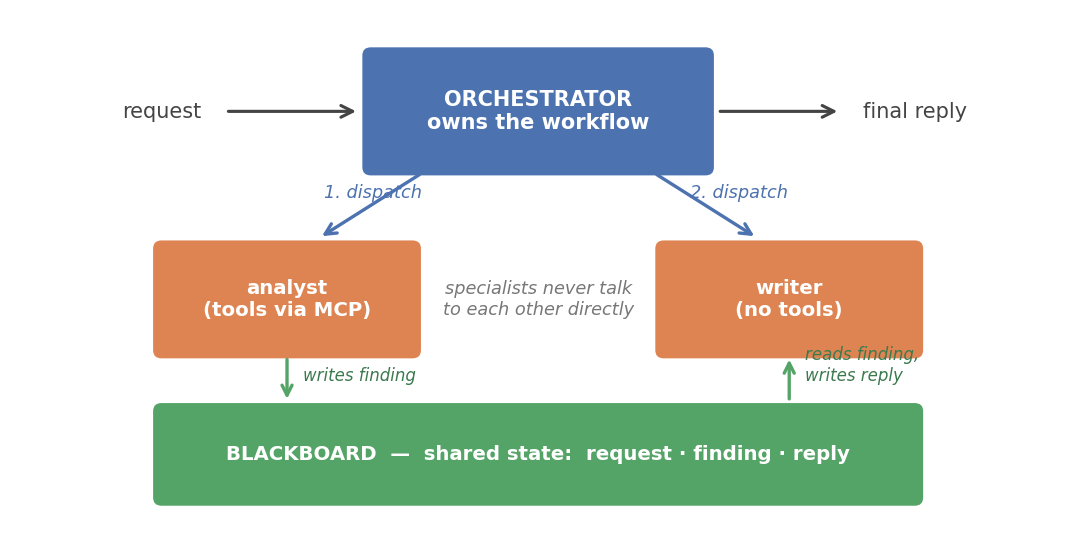

In [ ]:
class Orchestrator:
    def __init__(self, specialists: dict[str, Specialist]):
        self.specialists = specialists

    def run(self, request: str) -> dict:
        bb: dict = {"request": request}            # the shared blackboard
        print(f"📋 orchestrator received: {request!r}")
        # Step 1: analyst finds the metric
        bb["finding"] = self.specialists["analyst"](request, bb)
        # Step 2: writer phrases it
        bb["reply"] = self.specialists["writer"](request, bb)["reply"]
        print(f"✅ final reply: {bb['reply']}")
        return bb

orch = Orchestrator({"analyst": analyst, "writer": writer})
_ = orch.run("What's our phone CSAT and can you phrase it for a customer?")

---

### ✋ Quick exercise (~2 min) — Trace the blackboard

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Predict the **final reply** `orch.run` prints for the request below. Trace it in two steps: what does the analyst write to `bb["finding"]`, and how does the writer turn that into a sentence?

```python
orch.run("How many open tickets do we have?")
```

In [ ]:
# ✍️ Your turn 👇
# Predict the metric the analyst returns and the final reply the writer builds.
# Hint: TICKETS has two entries with status == "open".
# orch.run("How many open tickets do we have?")

<details>
<summary>✅ <b>Solution</b></summary>

```python
orch.run("How many open tickets do we have?")
# analyst -> bb["finding"] = {"metric": "open_tickets", "value": 2}
# writer  -> bb["reply"]   = "There are 2 open tickets right now."
```

The words `open`/`ticket` make the analyst count open tickets — 2 of the 3 in `TICKETS` — and write that to `bb["finding"]`. The writer then reads that finding off the blackboard and phrases the customer reply. Neither specialist talks to the other directly; the blackboard is their only shared channel.
</details>

## 5. Routing & handoff

Not every request needs every specialist. A **router** picks the entry specialist; **handoff** lets one agent pass control to another (e.g. analyst → writer, or escalate → human). Here's a router that sends pure-data questions straight to the analyst and phrasing requests through the full chain.

In [ ]:
def route(request: str) -> str:
    r = request.lower()
    if any(w in r for w in ("reply", "phrase", "customer", "draft", "email back")):
        return "full"          # analyst -> writer
    return "data_only"         # analyst only

def smart_run(orch: Orchestrator, request: str) -> dict:
    mode = route(request); bb = {"request": request, "mode": mode}
    bb["finding"] = orch.specialists["analyst"](request, bb)
    if mode == "full":
        bb["reply"] = orch.specialists["writer"](request, bb)["reply"]
    print(f"   routed as: {mode}")
    return bb

print(smart_run(orch, "How many open tickets?"))            # data_only
print(smart_run(orch, "Draft a customer reply about chat CSAT"))   # full chain

**Handoff** is more than routing: one agent *passes control to another* mid-task. The most valuable handoff is **escalation to a human** when no specialist can answer — far safer than letting an agent guess.

In [ ]:
def human_act(task, bb):
    return {"escalated": True, "ticket": f"ESC-{len(TICKETS)+1}", "reason": "no metric matched"}
human = Specialist("human", "Handles cases a model should not guess.", human_act)

def run_with_handoff(specs, request):
    bb = {"request": request}
    bb["finding"] = specs["analyst"](request, bb)
    if bb["finding"].get("metric") is None:          # analyst can't answer -> hand off
        bb["handoff"] = specs["human"](request, bb)
    else:
        bb["reply"] = specs["writer"](request, bb)["reply"]
    return bb

specs = {"analyst": analyst, "writer": writer, "human": human}
print(run_with_handoff(specs, "Draft a reply about chat CSAT"))    # analyst answers
print(run_with_handoff(specs, "What is the meaning of life?"))     # no metric -> escalates

---

### ✋ Quick exercise (~2 min) — Route or escalate?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Two requests arrive. Predict (a) the `mode` that `route()` assigns each, and (b) which one `run_with_handoff` escalates to the **human** specialist.

```python
a = "Email back the customer about phone CSAT"
b = "What's the capital of France?"
```

In [ ]:
# ✍️ Your turn 👇
# (a) route(a) -> ?   route(b) -> ?
# (b) which of a, b does run_with_handoff escalate to the human?
# a = "Email back the customer about phone CSAT"
# b = "What's the capital of France?"

<details>
<summary>✅ <b>Solution</b></summary>

```python
print(route("Email back the customer about phone CSAT"))   # -> 'full'
print(route("What's the capital of France?"))              # -> 'data_only'
run_with_handoff(specs, "What's the capital of France?")   # analyst finds no metric -> escalates to human
```

Request **a** contains `customer` and `email back`, so `route` picks the `full` analyst→writer chain. Request **b** has no metric keyword, so the analyst returns `metric: None`, and `run_with_handoff` hands control off to the `human` specialist instead of guessing.
</details>

## 6. Capstone — an MCP-backed support-operations assistant

Now the whole module in one system. We stand up a tiny **MCP server** (NB 33), connect a **client**, give the **analyst** its tools *through MCP* (so tools are discovered, not hard-coded), and let the **orchestrator** drive analyst → writer. Swap the offline brains for a real model and this is a shippable support copilot.

In [ ]:
# --- Compact MCP server + client (condensed from NB 33) ---------------------
def rpc(id, method, params=None): return {"jsonrpc": "2.0", "id": id, "method": method, "params": params or {}}

class MiniMCPServer:
    def __init__(self): self.tools = {}
    def add_tool(self, name, desc, fn): self.tools[name] = {"desc": desc, "fn": fn}
    def handle(self, req):
        m, p = req["method"], req.get("params", {})
        if m == "tools/list":
            return {"jsonrpc": "2.0", "id": req["id"],
                    "result": {"tools": [{"name": n, "description": t["desc"]}
                                         for n, t in self.tools.items()]}}
        if m == "tools/call":
            out = self.tools[p["name"]]["fn"](**p.get("arguments", {}))
            return {"jsonrpc": "2.0", "id": req["id"],
                    "result": {"content": [{"type": "text", "text": json.dumps(out)}]}}
        return {"jsonrpc": "2.0", "id": req["id"], "error": {"code": -32601, "message": m}}

class MiniMCPClient:
    def __init__(self, server): self.s = server; self._id = 0
    def _c(self, method, params=None):
        self._id += 1; r = self.s.handle(rpc(self._id, method, params))
        if "error" in r: raise RuntimeError(r["error"]["message"])
        return r["result"]
    def list_tools(self): return self._c("tools/list")["tools"]
    def call_tool(self, name, **a): return json.loads(self._c("tools/call",
                                    {"name": name, "arguments": a})["content"][0]["text"])

# Build the server
ops = MiniMCPServer()
ops.add_tool("get_csat", "CSAT for a channel.",
             lambda channel: {"channel": channel, "csat": CSAT.get(channel.lower())})
ops.add_tool("count_open", "Number of open tickets.",
             lambda: {"open": sum(t["status"] == "open" for t in TICKETS)})
ops_client = MiniMCPClient(ops)
print("server advertises:", [t["name"] for t in ops_client.list_tools()])

In [ ]:
# --- Analyst that uses the MCP client (tools discovered at runtime) ----------
def mcp_analyst_act(task, bb):
    tools = {t["name"] for t in ops_client.list_tools()}
    t = task.lower()
    if "csat" in t and "get_csat" in tools:
        ch = next((c for c in CSAT if c in t), "email")
        r = ops_client.call_tool("get_csat", channel=ch)
        return {"metric": "csat", "channel": r["channel"], "value": r["csat"]}
    if ("ticket" in t or "open" in t) and "count_open" in tools:
        return {"metric": "open_tickets", "value": ops_client.call_tool("count_open")["open"]}
    return {"metric": None}

mcp_analyst = Specialist("analyst", "Computes metrics via MCP tools.", mcp_analyst_act)
capstone = Orchestrator({"analyst": mcp_analyst, "writer": writer})

print("\n=== CAPSTONE RUN ===")
_ = capstone.run("A customer asked about phone support quality — draft a reply.")

## 7. Evaluating a multi-agent system

Test the **system**, not just the parts: feed end-to-end requests and assert the final reply is correct. A few golden cases catch most regressions when you later swap in a real model.

In [ ]:
CASES = [
    ("Draft a reply about phone CSAT", "4.4"),
    ("Draft a reply about chat CSAT",  "4.1"),
    ("Draft a reply about open tickets", "2"),
]
passed = 0
for request, expected in CASES:
    bb = capstone.run(request)
    ok = expected in bb.get("reply", "")
    passed += ok
    print(f"   {'✅' if ok else '❌'} expected {expected!r} in reply\n")
print(f"SYSTEM SCORE: {passed}/{len(CASES)}")

---

### ✋ Quick exercise (~2 min) — Add a golden case

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Extend the end-to-end test with one more golden case for the **email** channel. What `expected` substring should you assert appears in the reply? Fill it in and run the same `expected in reply` check the `CASES` loop uses.

```python
new_case = ("Draft a reply about email CSAT", "____")
```

In [ ]:
# ✍️ Your turn 👇
# Fill in the expected substring for the email channel, then run the CASES-style check.
# new_case = ("Draft a reply about email CSAT", "____")
# bb = capstone.run(new_case[0])
# print(new_case[1] in bb["reply"])

<details>
<summary>✅ <b>Solution</b></summary>

```python
new_case = ("Draft a reply about email CSAT", "3.6")
bb = capstone.run(new_case[0])
print(new_case[1] in bb["reply"])   # True
```

Email CSAT is `3.6` in the `CSAT` table, so the writer's reply must contain `"3.6"` — that's the golden expectation. The assertion is exactly the `expected in bb["reply"]` check the `CASES` loop already performs, just for one more channel.
</details>

## 8. Going live — the real multi-agent sketch

Offline, each `act()` is deterministic. With a real provider, each specialist is a `react_agent` (NB 31) whose system prompt is its `role`, whose tools come from an MCP client (NB 33), and whose output the orchestrator routes.

In [ ]:
# Reference only — the shape with a real model + MCP:
#
# from llm_providers import AnthropicLLM
# llm = AnthropicLLM(model="claude-haiku-4-5")
#
# def specialist_act(role, tools_client):
#     def act(task, bb):
#         schemas = tools_client.list_tools()
#         # run the NB 31 react loop with `role` as the system prompt and
#         # tools_client.call_tool as the executor; return the final answer.
#         ...
#     return act
#
# analyst = Specialist("analyst", "Compute metrics via tools.", specialist_act(...))
print("(reference — the offline orchestrator above is the runnable version)")

## 🧪 Practice exercises

### Exercise 1 — ⭐ Add a third specialist

Add a `critic` specialist that flags a reply if it contains no number, and call it on a draft.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def critic_act(task, bb):
    reply = bb.get("reply", "")
    return {"ok": bool(re.search(r"\d", reply)), "reply": reply}

critic = Specialist("critic", "Checks replies are grounded.", critic_act)
bb = capstone.run("Draft a reply about chat CSAT")
print(critic("review", bb))
```

**Reasoning:** A critic is just another specialist: it reads the shared blackboard (the reply), applies a cheap check — a grounded reply should contain at least one number — and returns a verdict. Plugging it in requires no changes to the orchestrator or other specialists.
</details>

### Exercise 2 — ⭐⭐ A new tool, zero analyst changes

Add a `worst_channel` tool to the MCP server and confirm `list_tools()` shows it without touching the client.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
ops.add_tool("worst_channel", "Channel with the lowest CSAT.",
             lambda: {"channel": min(CSAT, key=CSAT.get), "csat": min(CSAT.values())})
print([t["name"] for t in ops_client.list_tools()])
print(ops_client.call_tool("worst_channel"))
```

**Reasoning:** The tool is added to the *server*; the analyst discovers tools through `list_tools()` at runtime, so the new capability appears with zero client or analyst changes. That late binding is what makes MCP-backed agents extensible.
</details>

### Exercise 3 — ⭐⭐ Count specialist calls

Wrap `Specialist.__call__` usage to count how many times each specialist runs during a capstone request (a basic cost metric).

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
calls = {}
def counting(spec):
    def wrapped(task, bb):
        calls[spec.name] = calls.get(spec.name, 0) + 1
        return spec.act(task, bb)
    return Specialist(spec.name, spec.role, wrapped)

c_orch = Orchestrator({"analyst": counting(mcp_analyst), "writer": counting(writer)})
c_orch.run("Draft a reply about phone CSAT")
print("specialist calls:", calls)
```

**Reasoning:** Wrapping each specialist's `act` in a counting closure (and rebuilding the orchestrator with the wrapped versions) gives a per-specialist call count without touching the `Specialist` class — a minimal cost/usage metric you'd export to monitoring in production.
</details>

### Exercise 4 — ⭐⭐ Debug me 🐞

This loop is meant to print each case's expected value, but it errors. Read it, then fix (expand the solution below when ready).

In [ ]:
# 🐞 BUG (INTENTIONALLY ERRORS): unpacking a 2-tuple into 3 names.
for request, expected, mode in CASES:
    print(request, "->", expected)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
# ✅ Fix: CASES holds (request, expected) pairs — unpack two.
for request, expected in CASES:
    print(request, "->", expected)
```

**Reasoning:** `CASES` holds `(request, expected)` 2-tuples, so unpacking three names raises `ValueError`. Match the unpacking to the data shape — or, if you *want* a third field, change the data, not just the loop.
</details>

## 🧠 Stretch exercises

### Stretch A — ⭐⭐⭐ Parallel specialists

When sub-tasks are independent (e.g. fetch CSAT *and* ticket count), run two analyst calls in parallel and merge the findings.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from concurrent.futures import ThreadPoolExecutor
def parallel_findings(requests):
    with ThreadPoolExecutor(max_workers=4) as pool:
        return list(pool.map(lambda r: mcp_analyst_act(r, {}), requests))

print(parallel_findings(["phone csat", "open tickets", "chat csat"]))
```

**Reasoning:** The two analyst calls are independent — neither needs the other's output — so they can run concurrently in a thread pool; each call gets its own empty blackboard to avoid shared-state races. Parallelise *independent* sub-tasks only; dependent steps must stay sequential.
</details>

### Stretch B — ⭐⭐⭐ Orchestrator with a budget

Give the orchestrator a `max_specialist_calls` budget and stop once it's hit — the multi-agent version of NB 31's step budget.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def budgeted_run(specs, request, budget=2):
    bb, used = {"request": request}, 0
    for name in ("analyst", "writer"):
        if used >= budget: bb["stopped"] = f"budget {budget} hit"; break
        out = specs[name].act(request, bb); used += 1
        bb["finding" if name == "analyst" else "reply"] = out if name == "analyst" else out["reply"]
    return bb

print(budgeted_run({"analyst": mcp_analyst, "writer": writer}, "Draft a reply about chat CSAT", budget=2))
print(budgeted_run({"analyst": mcp_analyst, "writer": writer}, "Draft a reply about chat CSAT", budget=1))
```

**Reasoning:** The budget counts specialist invocations and is checked *before* each dispatch; when it's hit, the run stops and records why on the blackboard instead of failing silently. Same idea as NB 31's step budget, one level up — bound the orchestrator, not just the agent.
</details>

### Stretch C — ⭐⭐⭐ Capability-based routing

Hard-coding "analyst then writer" doesn't scale to many specialists. Let each specialist **declare which requests it can handle**, and route by capability — falling back to a human when nobody can.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
REGISTRY = [
    ("analyst", lambda r: any(w in r.lower() for w in ("csat", "ticket", "open"))),
    ("writer",  lambda r: any(w in r.lower() for w in ("reply", "draft", "phrase", "customer"))),
]
def capabilities_for(request):
    caps = [name for name, can in REGISTRY if can(request)]
    return caps or ["human"]          # nobody can handle it -> escalate

print("Draft a reply about phone CSAT ->", capabilities_for("Draft a reply about phone CSAT"))
print("How many open tickets?        ->", capabilities_for("How many open tickets?"))
print("What is the meaning of life?  ->", capabilities_for("What is the meaning of life?"))
```

**Reasoning:** Each specialist declares a `can(request)` predicate, so routing becomes data (`REGISTRY`) instead of hard-coded control flow — adding a specialist is one registry entry. The `["human"]` fallback guarantees an unhandleable request escalates instead of being guessed at.
</details>

### Stretch D — ⭐⭐⭐ A blackboard log

Record every write to the blackboard with the specialist that made it, so you can replay how a decision was reached (multi-agent observability).

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
class LoggedBlackboard(dict):
    def __init__(self): super().__init__(); self.history = []
    def write(self, who, key, value):
        self[key] = value; self.history.append({"by": who, "key": key})

lb = LoggedBlackboard()
lb.write("analyst", "finding", mcp_analyst_act("phone csat", {}))
lb.write("writer", "reply", writer_act("draft", lb)["reply"])
print("final reply:", lb["reply"])
print("audit trail:", lb.history)
```

**Reasoning:** Subclassing `dict` keeps the blackboard a drop-in replacement, while `write` records *who* wrote *which* key. The history is a replayable audit trail — multi-agent observability in a dozen lines.
</details>

## 🎁 Bonus mini-project — the full assistant as one function

Wrap the capstone into `support_assistant(request)` that routes, runs the right specialists through MCP, critiques the reply, and returns a structured result. This is the module's finished artifact — and the template for any real agentic product you build next.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def support_assistant(request: str) -> dict:
    bb = {"request": request, "mode": route(request)}
    bb["finding"] = mcp_analyst_act(request, bb)
    if bb["finding"].get("metric") is None:                 # no metric -> escalate
        esc = human_act(request, bb)
        bb["escalation"] = esc                              # structured detail kept separately
        bb["reply"] = f"Escalated as {esc['ticket']}: {esc['reason']}"
        bb["grounded"] = False
    elif bb["mode"] == "full":                              # phrase it for a customer
        bb["reply"] = writer_act(request, bb)["reply"]
        bb["grounded"] = bool(re.search(r"\d", bb["reply"]))
    else:                                                   # data-only: state the metric plainly
        f = bb["finding"]
        bb["reply"] = f"{f.get('channel', '')} {f['metric']} = {f['value']}".strip()
        bb["grounded"] = True
    return bb

print(json.dumps(support_assistant("Draft a customer reply about phone CSAT"), indent=2))
```

**Reasoning:** One function = the whole architecture: route to pick the mode, analyst (through MCP) for grounding, writer only when a customer-facing phrasing is wanted, human escalation when no metric exists, and a final groundedness check. The structured dict it returns is the contract a real product would build on.
</details>

## 🧠 Key takeaways

> 🧭 **Back to the team — and the whole module.** Every pattern here was the *team* picture from the intro: a **specialist** is one team member with a narrow role and a subset of tools; **routing** is the lead deciding who takes the request; **handoff** is one member passing work to another (or escalating to a human); the **blackboard** is the shared whiteboard they all read and write; and **evaluation** is reviewing the team's *output*, not each member in isolation. The capstone hired the whole team onto the **AI support copilot** we've built since Notebook 31 — and notice how cleanly the four notebooks stacked: the **loop** (NB 31) gave each agent its brain, **robust tools** (NB 32) made its actions safe, **MCP** (NB 33) let it reach those tools from anywhere, and **multi-agent** (here) let several copies collaborate. Same scenario, four layers, one shippable assistant. That layering — *loop → tools → protocol → team* — is the mental model to carry into whatever you build next.

1. **Reach for multiple agents only when sub-tasks differ** in tools, instructions, owners, or need independent review — otherwise one agent wins.
2. The **orchestrator–worker** pattern keeps the workflow in one place; specialists stay narrow and testable.
3. **Route** to the right specialist and **hand off** (including to a human) instead of guessing.
4. Share state through a **blackboard**; log writes for observability.
5. **Evaluate the whole system** with golden end-to-end cases, not just unit pieces.
6. The capstone shows the module's stack end-to-end: **agents (31) + robust tools (32) + MCP (33)** → a real support copilot.
7. Every offline brain here swaps for a real model with **no change to the orchestration.**

## ✅ Self-assessment

- [ ] State when a multi-agent design is worth its cost
- [ ] Build an orchestrator that routes between specialist agents
- [ ] Pass state via a blackboard and add an escalation handoff
- [ ] Give the analyst its tools through an MCP client
- [ ] Evaluate the system with end-to-end golden cases
- [ ] Explain how to swap the offline brains for a real model

## 🎓 That's a wrap on Module 8!

You've reached the end of **Module 8 — Agents, Tools & MCP**. You've gone from Python fundamentals to data science, machine learning, AI engineering, production systems — and now a multi-agent, MCP-backed support copilot built entirely from pieces you understand. That's a serious milestone, and you built it yourself. 🎉 The course continues with **Modules 9–14 (NB 35–46)**, so there's more ahead when you're ready.

If you'd like a final check of this module, the quiz at [`../quizzes/quiz_08_agents_tools_mcp.ipynb`](../quizzes/quiz_08_agents_tools_mcp.ipynb) is an optional way to test yourself.

## 🚀 Where to go next

You've completed **Module 8 — Agents, Tools & MCP**. From here:

- **Ship it:** turn the capstone server into a real **`mcp` FastMCP** server (NB 33 §9) and register it with **Claude Desktop** or **Claude Code**.
- **Go deeper:** revisit **Module 7 (Building AI POCs)** and **Module 6 (AI Engineering)** with agent eyes.
- **Build something:** point an orchestrator at *your* data via an MCP server — that's a portfolio project.